In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ( accuracy_score , confusion_matrix, classification_report , ConfusionMatrixDisplay , roc_curve,auc)
plt.style.use("ggplot")


In [95]:
df = df = pd.read_csv("heart.csv")

In [58]:
print(df.head)

<bound method NDFrame.head of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2  

In [59]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [60]:
df.shape

(1025, 14)

In [61]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [62]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 723


In [63]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (302, 14)


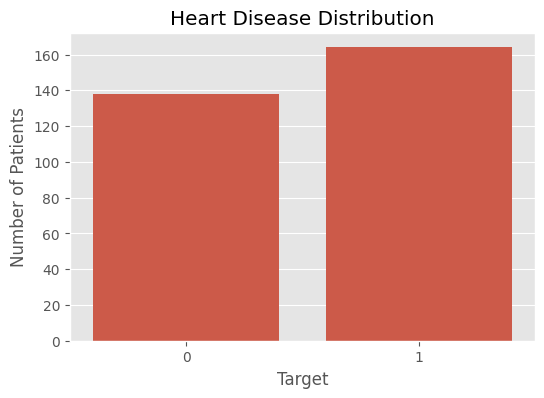

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

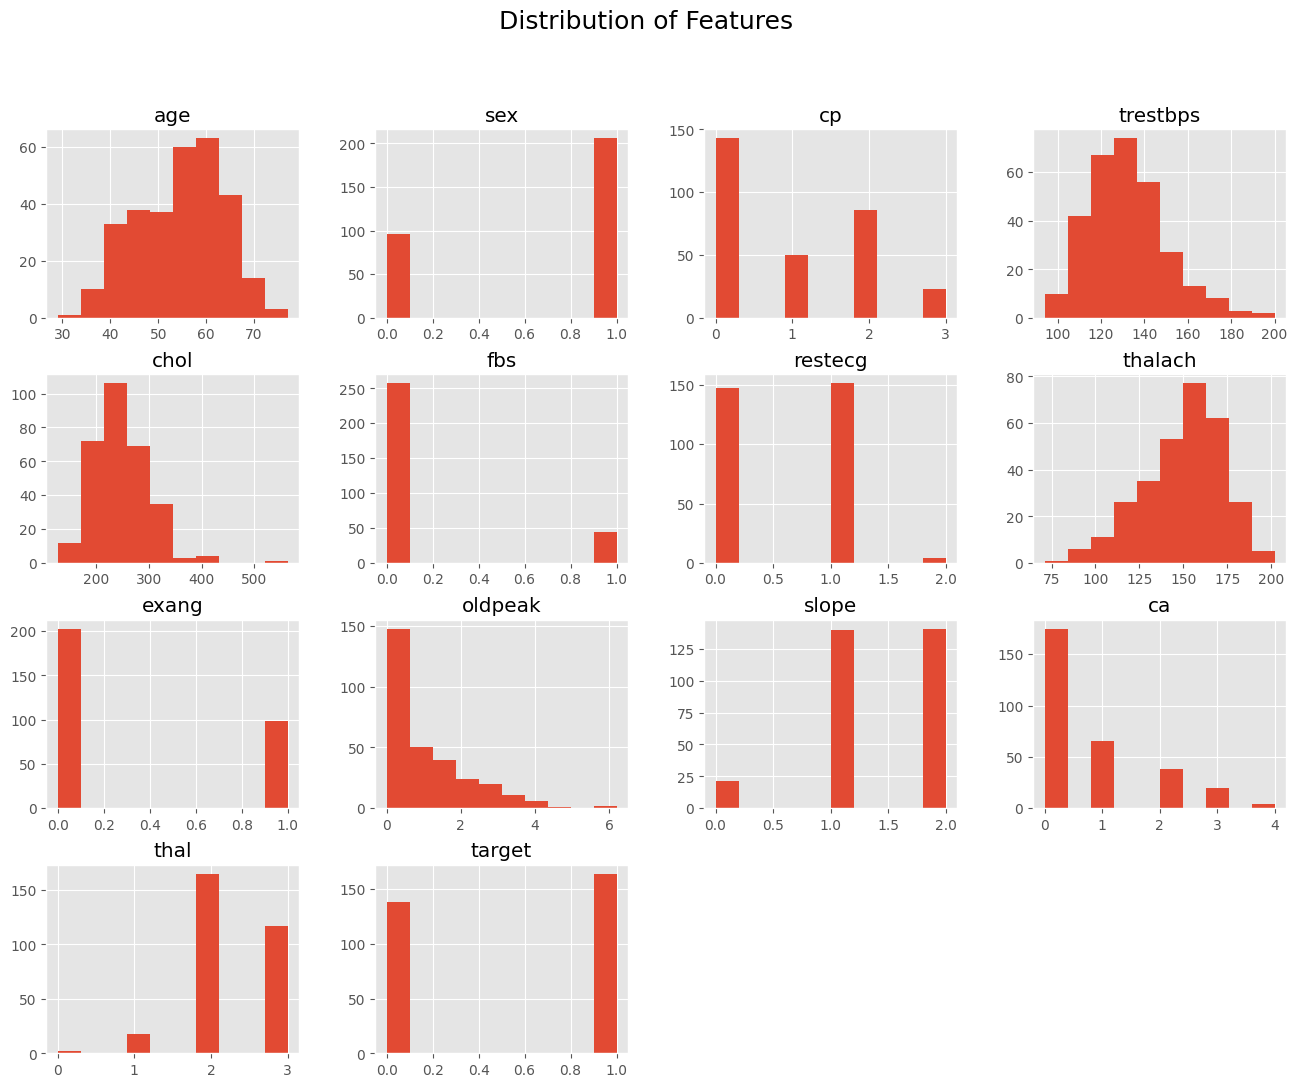

In [65]:
df.hist(figsize=(16,12))

plt.suptitle("Distribution of Features", fontsize=18)

plt.show()

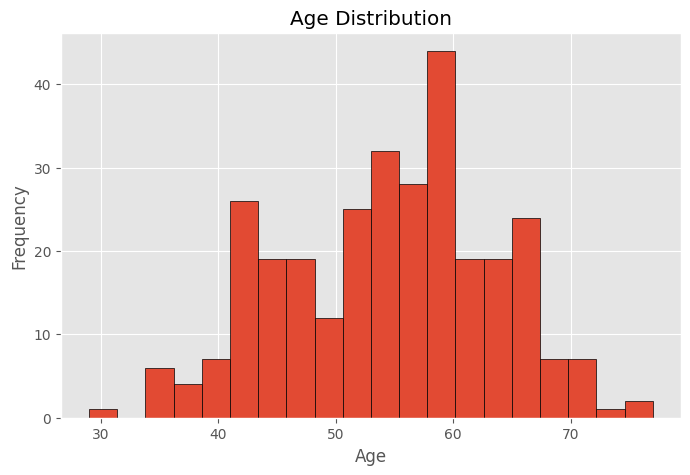

In [66]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

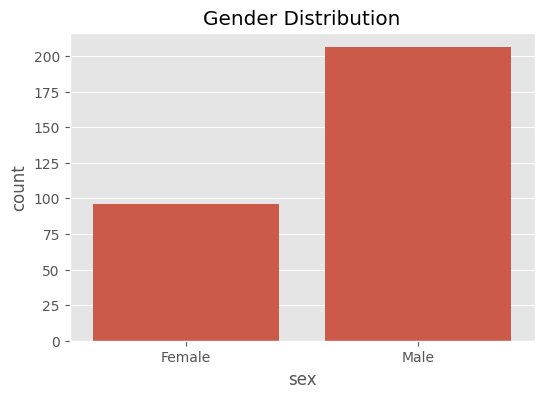

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")

plt.xticks([0,1],["Female","Male"])

plt.show()

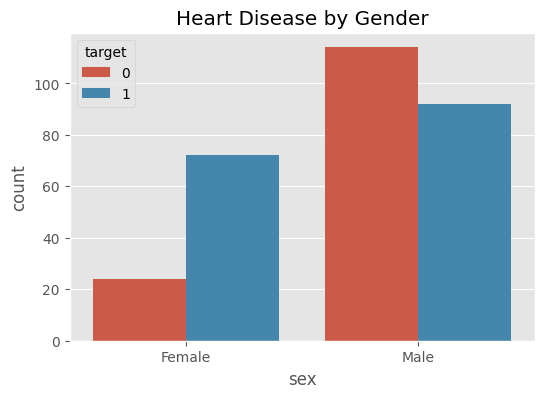

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", hue="target", data=df)

plt.xticks([0,1],["Female","Male"])

plt.title("Heart Disease by Gender")

plt.show()

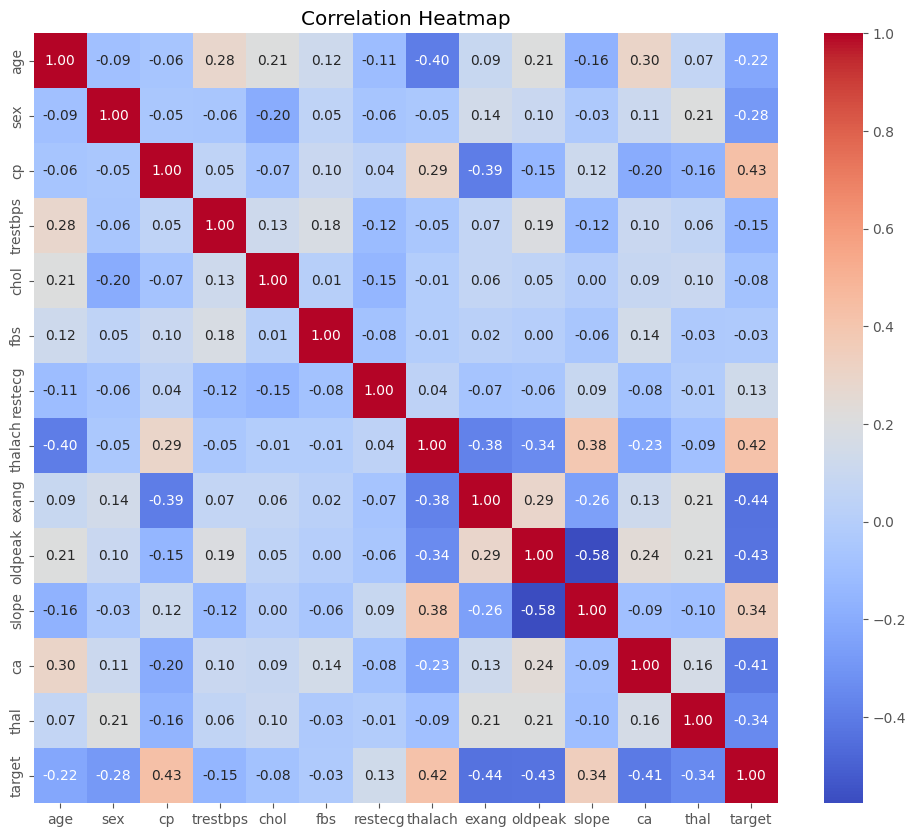

In [69]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

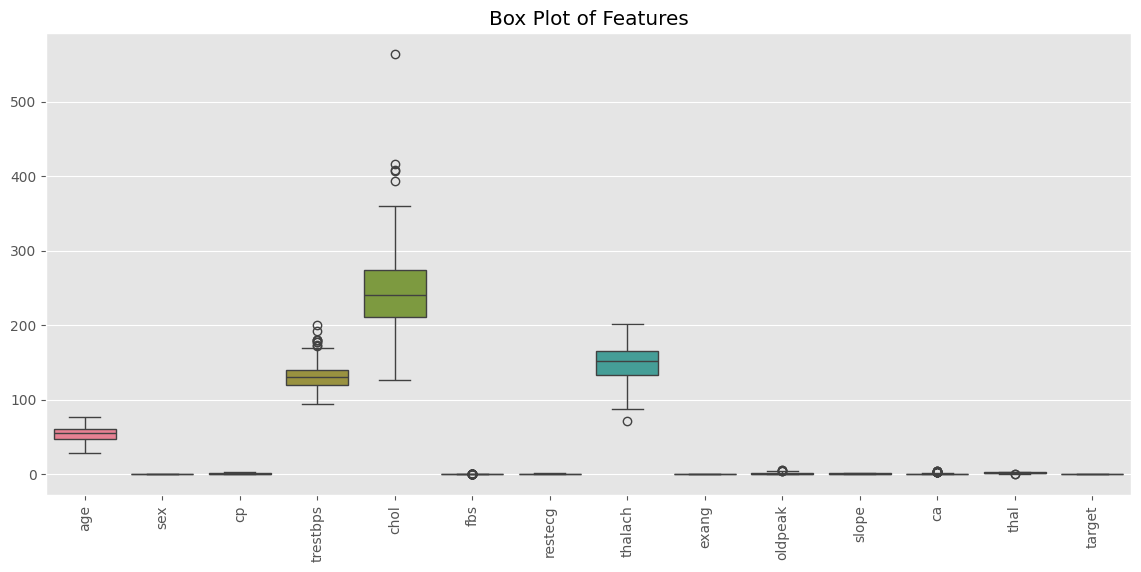

In [70]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Box Plot of Features")

plt.show()

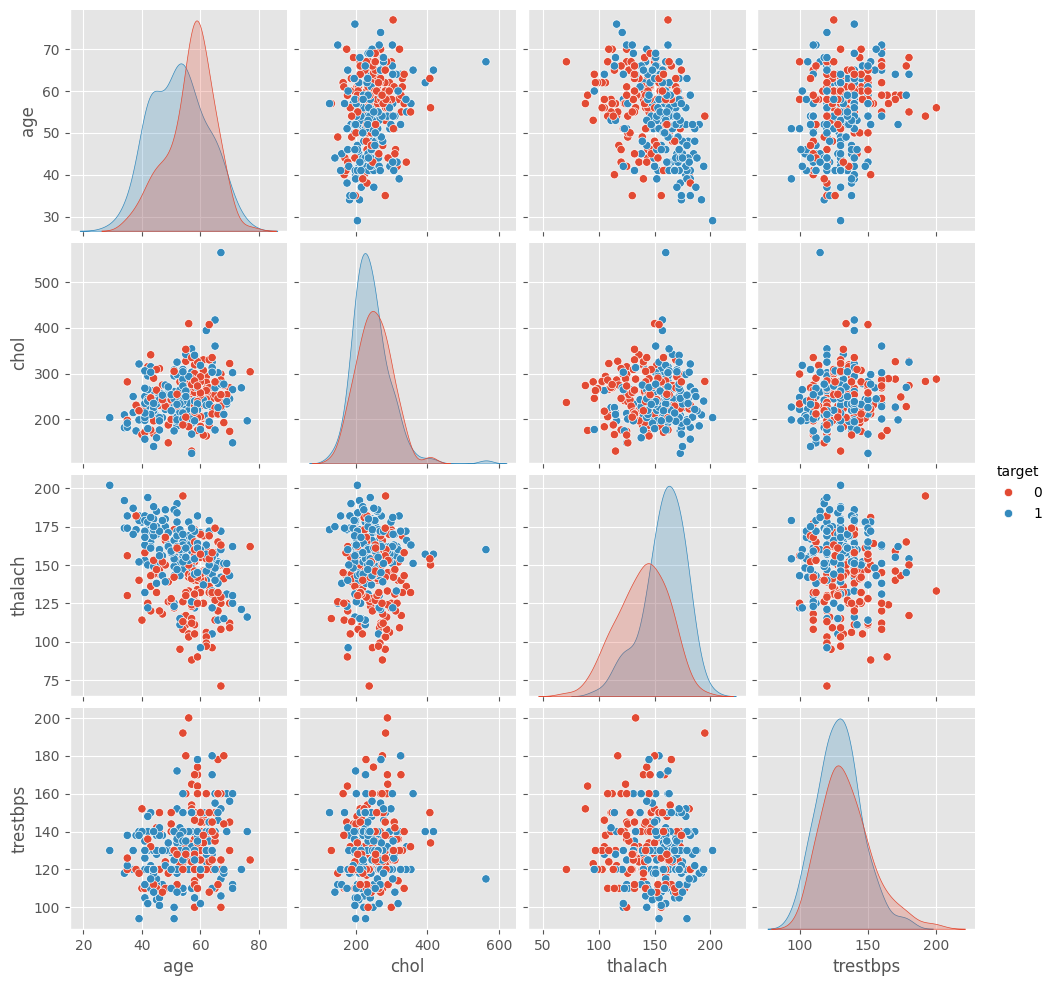

In [71]:
sns.pairplot(
    df,
    hue="target",
    vars=["age","chol","thalach","trestbps"]
)

plt.show()

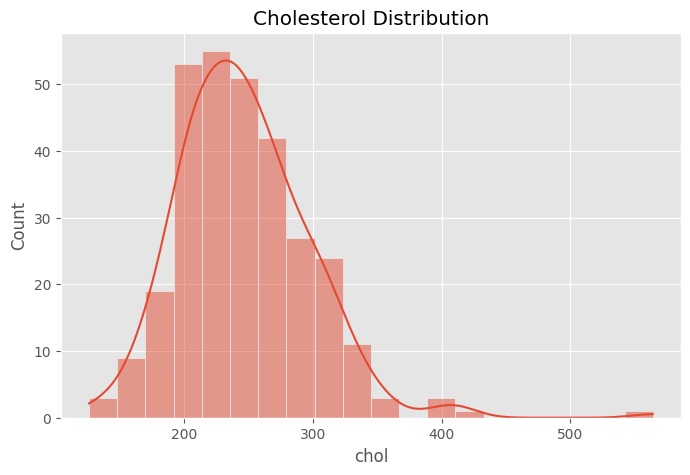

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(df["chol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")

plt.show()

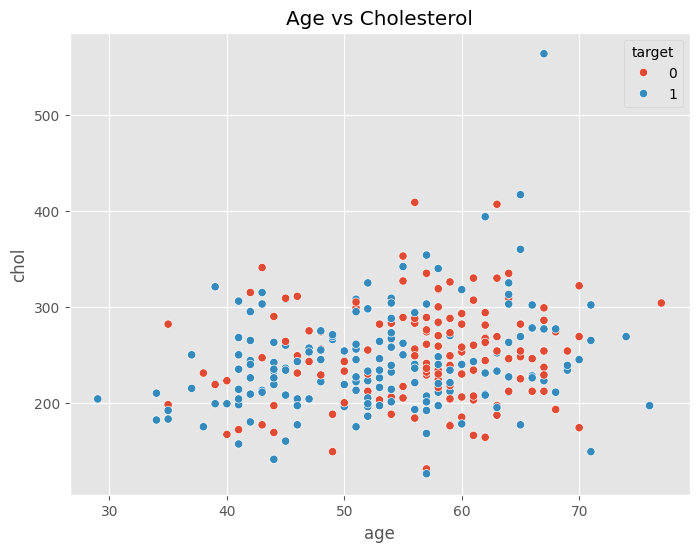

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="age",
    y="chol",
    hue="target",
    data=df
)

plt.title("Age vs Cholesterol")

plt.show()

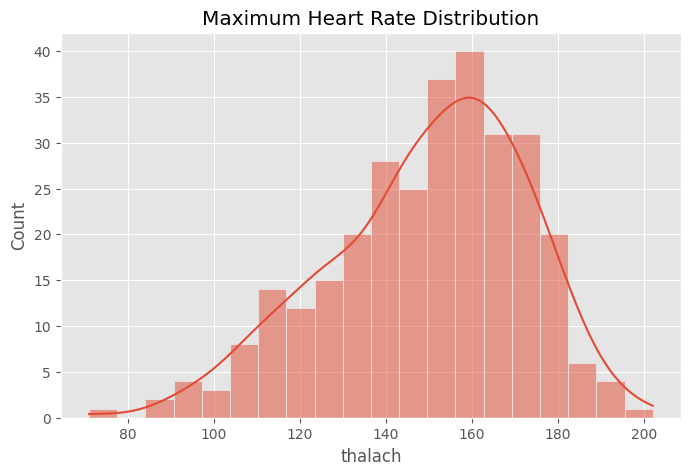

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(df["thalach"], bins=20, kde=True)

plt.title("Maximum Heart Rate Distribution")

plt.show()

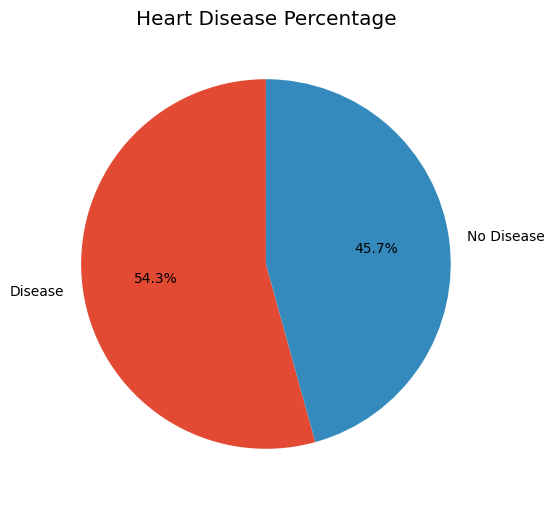

In [75]:
target_counts = df["target"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["Disease","No Disease"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Heart Disease Percentage")

plt.show()

In [76]:
# Features (Input)
X = df.drop("target", axis=1)

# Target (Output)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (302, 13)
Target Shape: (302,)


In [77]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [78]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [80]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (241, 13)
Testing Features: (61, 13)
Training Labels: (241,)
Testing Labels: (61,)


In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [82]:
print(X_train[:5])

[[-0.68263287  0.6852096  -0.98005432 -0.40315275  0.48628088 -0.42587856
  -1.02487724  0.71700677 -0.71813875 -0.44752381 -0.71553867 -0.70553555
   1.1181192 ]
 [ 0.40398881  0.6852096  -0.98005432 -0.17140603  0.20631506 -0.42587856
  -1.02487724 -0.83662728  1.39248856  1.76803161 -0.71553867  1.24887901
   1.1181192 ]
 [-1.00861938 -1.45940746 -0.00404981 -0.05553267 -0.26029464 -0.42587856
  -1.02487724  1.10541528 -0.71813875 -0.35890159 -0.71553867 -0.70553555
  -0.54525566]
 [-1.11728155  0.6852096  -0.00404981 -0.63489947 -0.52159607 -0.42587856
   0.86058394  0.88963277 -0.71813875 -0.89063489  0.99183578 -0.70553555
  -0.54525566]
 [ 0.83863748 -1.45940746 -0.98005432  1.10320093 -0.07365076 -0.42587856
   0.86058394  0.19912875  1.39248856  0.35007614 -0.71553867 -0.70553555
  -0.54525566]]


In [83]:
print("Mean:", X_train.mean())
print("Standard Deviation:", X_train.std())

Mean: 3.7420859048967935e-17
Standard Deviation: 1.0


In [84]:
mlp = MLPClassifier(hidden_layer_sizes=(20, 20),activation="relu",solver="adam",max_iter=1000,random_state=42)

In [85]:
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [86]:
print("Final Loss:", mlp.loss_)

Final Loss: 0.021909411289337603


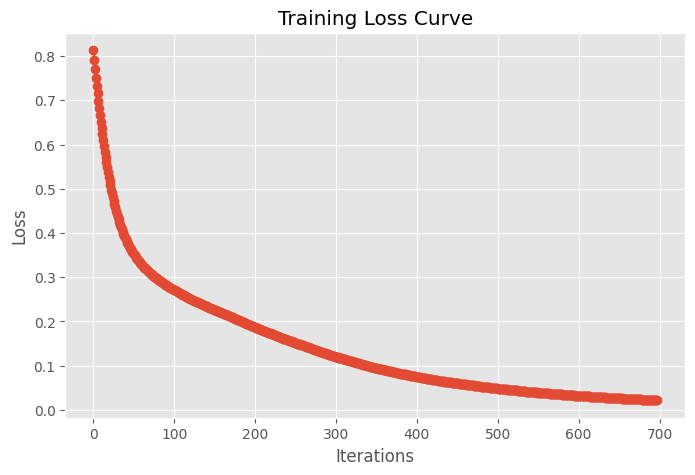

In [87]:


plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_, marker='o')

plt.title("Training Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [88]:
y_pred = mlp.predict(X_test)

In [89]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       1          1
1       0          1
2       0          0
3       1          0
4       1          0
5       0          0
6       0          0
7       1          0
8       1          1
9       0          0


In [90]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7377049180327869


In [91]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[26  6]
 [10 19]]


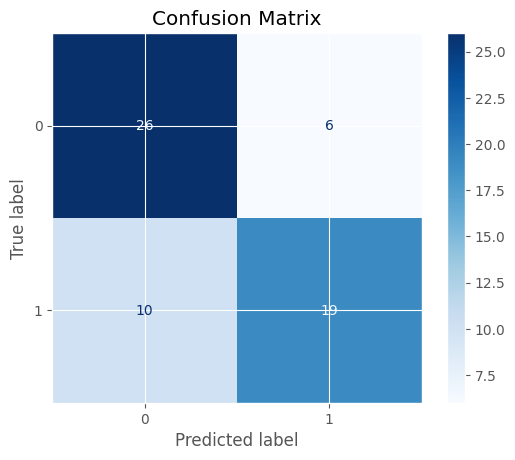

In [92]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.81      0.76        32
           1       0.76      0.66      0.70        29

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



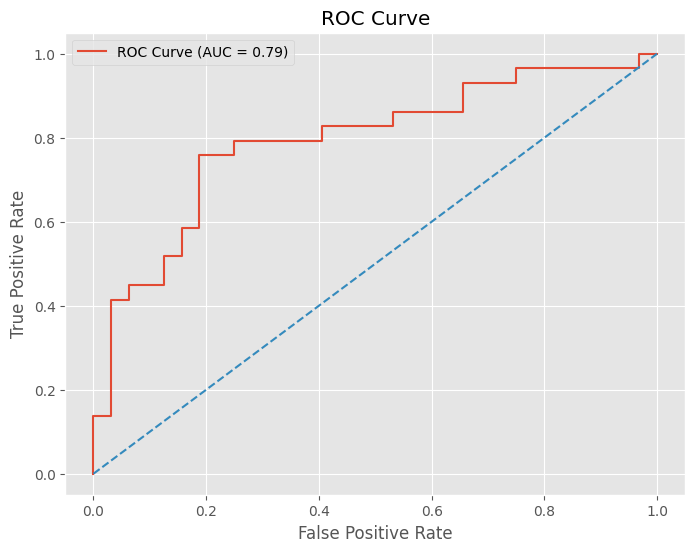

In [96]:
y_prob = mlp.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [97]:
sample = [[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]]

sample_scaled = scaler.transform(sample)

prediction = mlp.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [98]:
import joblib

joblib.dump(mlp, "heart_disease_mlp_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
